In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from statsmodels.stats.mediation import Mediation
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
from pingouin import ancova
import matplotlib.cm as cm
from scipy.stats.stats import pearsonr


%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

/tmp/ipykernel_821654/3379509306.py:18: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr


# 1 Load data from "2 BrainAge"

In [48]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_edu_main_test.pkl")
main_train = pd.read_pickle("2_edu_main_train.pkl")
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Preprocessing and descriptives

## 2.1 Data

In [49]:
main_test.head()

,ID,Age,Sex,IS,TPA,VPA,MPA,MVPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,EDUL,BADA2009,BADASEG,BADDesikan,BADCombined
10,1001365,71.0,Female,11025,3396.9600,20.1600,514.0800,554.4000,2862.7200,594.0,240.0,240.0,20.0,73.0,28.2030,70.0,106.0,O levels/GCSEs or equivalent,-3.403180,-4.127091,-0.686515,-4.451760
17,1001748,48.0,Female,11025,3126.8160,265.3056,596.9376,1127.5488,2264.5728,462.0,0.0,2400.0,34.0,52.0,25.7857,75.0,124.0,O levels/GCSEs or equivalent,4.049462,-3.686989,4.838212,-0.661371
20,1001984,69.0,Female,11026,2468.4192,9.9936,579.6288,599.6160,1878.7968,693.0,960.0,0.0,26.0,76.0,25.7422,79.0,120.0,O levels/GCSEs or equivalent,1.560255,-2.585316,-7.421234,-0.401026
21,1002138,56.0,Female,11025,2465.2224,29.1168,427.0464,485.2800,2009.0592,2970.0,720.0,240.0,18.0,56.0,33.5680,75.0,134.0,O levels/GCSEs or equivalent,-4.910616,-13.644097,1.806277,-4.971561
23,1002288,63.0,Female,11025,2559.7728,109.1376,704.4336,922.7088,1746.2016,264.0,960.0,0.0,30.0,85.0,27.4762,84.0,146.0,College or University degree,-5.114916,-5.080955,-4.510455,-3.602327


## 2.2 Remove outliers on SR PA

In [50]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 545
5427


## 2.3 Convert SRPA from MET min/week to min/week

In [51]:
main_test["SRLPA"] = main_test["SRLPA"]/3.3
main_test["SRMPA"] = main_test["SRMPA"]/4
main_test["SRVPA"] = main_test["SRVPA"]/8

main_train["SRLPA"] = main_train["SRLPA"]/3.3
main_train["SRMPA"] = main_train["SRMPA"]/4
main_train["SRVPA"] = main_train["SRVPA"]/8

## 2.4 Test set descriptives

In [52]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Sex"] == "Female"]
male = main_test[main_test["Sex"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_test["Age"].mean()
print("Mean", mean)
std = main_test["Age"].std()
print("Std",std)

print("LPA")
mean = main_test["LPA"].mean()
print("Mean", mean)
std = main_test["LPA"].std()
print("Std",std)

print("MPA")
mean = main_test["MPA"].mean()
print("Mean", mean)
std = main_test["MPA"].std()
print("Std",std)

print("VPA")
mean = main_test["VPA"].mean()
print("Mean", mean)
std = main_test["VPA"].std()
print("Std",std)

print("SRLPA")
mean = main_test["SRLPA"].mean()
print("Mean", mean)
std = main_test["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_test["SRMPA"].mean()
print("Mean", mean)
std = main_test["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_test["SRVPA"].mean()
print("Mean", mean)
std = main_test["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_test["DBP"].mean()
print("Mean", mean)
std = main_test["DBP"].std()
print("Std",std)

print("SBP")
mean = main_test["SBP"].mean()
print("Mean", mean)
std = main_test["SBP"].std()
print("Std",std)

print("BMI")
mean = main_test["BMI"].mean()
print("Mean", mean)
std = main_test["BMI"].std()
print("Std",std)

print("HG")
mean = main_test["HG"].mean()
print("Mean", mean)
std = main_test["HG"].std()
print("Std",std)

print("HR")
mean = main_test["HR"].mean()
print("Mean", mean)
std = main_test["HR"].std()
print("Std",std)

print("IS")
print(main_test["IS"].value_counts())

print("EDUL")
print(main_test["EDUL"].value_counts())

Number of females: 2968
NUmber of males: 2459
Age
Mean 64.2666298138935
Std 7.76525271780262
LPA
Mean 1982.265806965174
Std 412.4967684595618
MPA
Mean 482.29192437810946
Std 221.2515175869221
VPA
Mean 33.79209286898842
Std 42.89737084919924
SRLPA
Mean 235.28431914501567
Std 220.0228057976212
SRMPA
Mean 159.35784042749216
Std 193.01692365860208
SRVPA
Mean 64.9268472452552
Std 83.01547730757983
DBP
Mean 81.13082734475769
Std 10.420898158367109
SBP
Mean 136.23659480375898
Std 18.55147058506162
BMI
Mean 26.456102561267738
Std 4.250126002179229
HG
Mean 33.31453841901603
Std 10.804499367526754
HR
Mean 68.11498065229408
Std 10.782063952360506
IS
11025    3316
11027    1181
11026     924
11028       6
Name: IS, dtype: int64
EDUL
College or University degree                               2820
O levels/GCSEs or equivalent                               1019
A levels/AS levels or equivalent                            710
NVQ or HND or HNC or equivalent                             252
Other profess

## 2.6 Train set descriptives

In [53]:
# get mean and std for all variables for males and females seperately for the test set
female = main_train[main_train["Sex"] == "Female"]
male = main_train[main_train["Sex"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_train["Age"].mean()
print("Mean", mean)
std = main_train["Age"].std()
print("Std",std)

print("SRLPA")
mean = main_train["SRLPA"].mean()
print("Mean", mean)
std = main_train["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_train["SRMPA"].mean()
print("Mean", mean)
std = main_train["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_train["SRVPA"].mean()
print("Mean", mean)
std = main_train["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_train["DBP"].mean()
print("Mean", mean)
std = main_train["DBP"].std()
print("Std",std)

print("SBP")
mean = main_train["SBP"].mean()
print("Mean", mean)
std = main_train["SBP"].std()
print("Std",std)

print("BMI")
mean = main_train["BMI"].mean()
print("Mean", mean)
std = main_train["BMI"].std()
print("Std",std)

print("HG")
mean = main_train["HG"].mean()
print("Mean", mean)
std = main_train["HG"].std()
print("Std",std)

print("HR")
mean = main_train["HR"].mean()
print("Mean", mean)
std = main_train["HR"].std()
print("Std",std)

print("IS")
print(main_train["IS"].value_counts())

print("EDUL")
print(main_train["EDUL"].value_counts())

Number of females: 11117
NUmber of males: 10325
Age
Mean 64.39889002891522
Std 7.649732872523935
SRLPA
Mean 289.784948011223
Std 309.29411344455514
SRMPA
Mean 206.94867139792044
Std 280.6411674181547
SRVPA
Mean 82.22308411729108
Std 130.49491812800625
DBP
Mean 81.29120713856025
Std 10.363904029343296
SBP
Mean 136.45067174654102
Std 18.67013239738352
BMI
Mean 26.645524985989166
Std 4.237943939447412
HG
Mean 33.90108039848464
Std 11.262323642066619
HR
Mean 68.077150591538
Std 10.972897755270589
IS
11025    12729
11027     5651
11026     3034
11028       28
Name: IS, dtype: int64
EDUL
College or University degree                               9621
O levels/GCSEs or equivalent                               4155
A levels/AS levels or equivalent                           2718
None of the above                                          1458
NVQ or HND or HNC or equivalent                            1184
Other professional qualifications eg: nursing, teaching    1046
CSEs or equivalent         

## 2.8 Physical activity

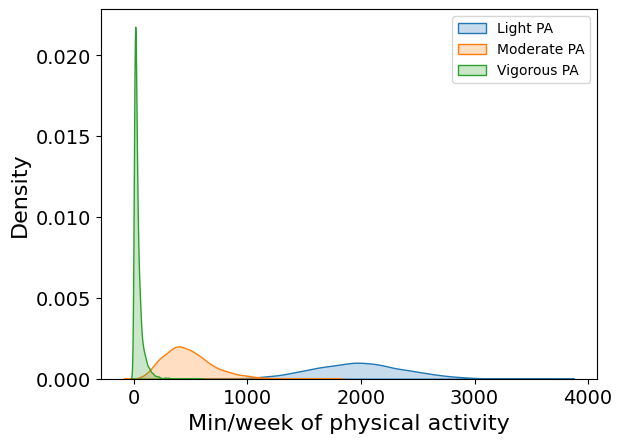

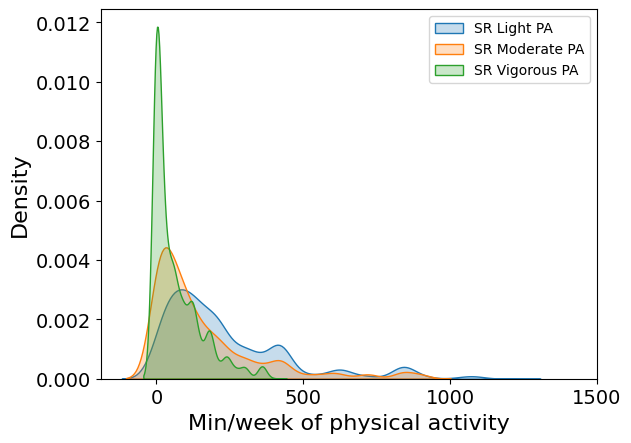

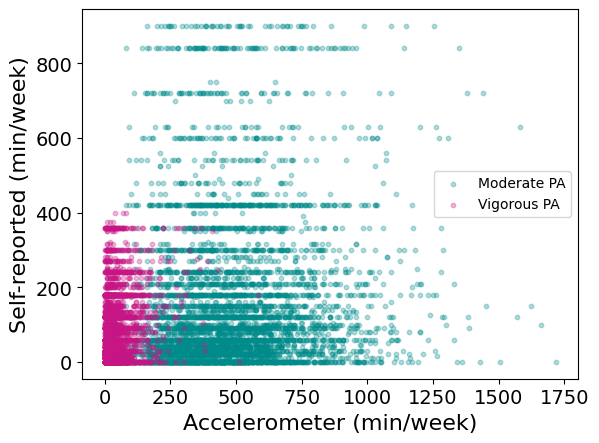

In [54]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately

plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,5000,1000),fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.yticks(fontsize = 14)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2000,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
# sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,4500,1000),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
# sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,2500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
# sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
# plt.ylim(0,0.01)
# plt.xticks(range(0,1500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.legend()
# plt.show()

plt.figure()
plt.scatter("MPA", "SRMPA", data = main_test, label = "Moderate PA", alpha=0.3, s=10, color = "darkcyan")
plt.scatter("VPA", "SRVPA", data = main_test, label = "Vigorous PA", alpha=0.3, s=10, color = "mediumvioletred")
plt.ylabel("Self-reported (min/week)", fontsize = 16)
plt.xlabel("Accelerometer (min/week)", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc="best")
plt.show()

# 3 Recode variables

In [55]:
# recode Imaging site and Gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 0, '11026': 1,'11027': 2, '11028': 3})
# fix this
main_test['EDUL'] = main_test['EDUL'].map({'None of the above': 0, 'Other professional qualifications eg: nursing, teaching': 5,'NVQ or HND or HNC or equivalent': 4, 'CSEs or equivalent': 1, 'O levels/GCSEs or equivalent':2, 'A levels/AS levels or equivalent':3,'College or University degree':6})
main_test["Sex"] = main_test["Sex"].map({"Female":0, "Male":1})
main_test["Sex"] = main_test["Sex"].astype("int")
main_test = main_test.rename(columns={"BADCombined": "BA"})

print("EDU")
print(main_test["EDUL"].value_counts())

EDU
6.0    2820
2.0    1019
3.0     710
4.0     252
5.0     235
0.0     231
1.0     160
Name: EDUL, dtype: int64


# 4 Reorder dataframe and delete unused variables

In [56]:
main_test = main_test[['Age', 'Sex', 'IS' , "EDUL", 'LPA', 'MPA', 'VPA', 'SRLPA', 'SRMPA', 'SRVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', 'BA']]

# 5 Correlation heatmap

In [57]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

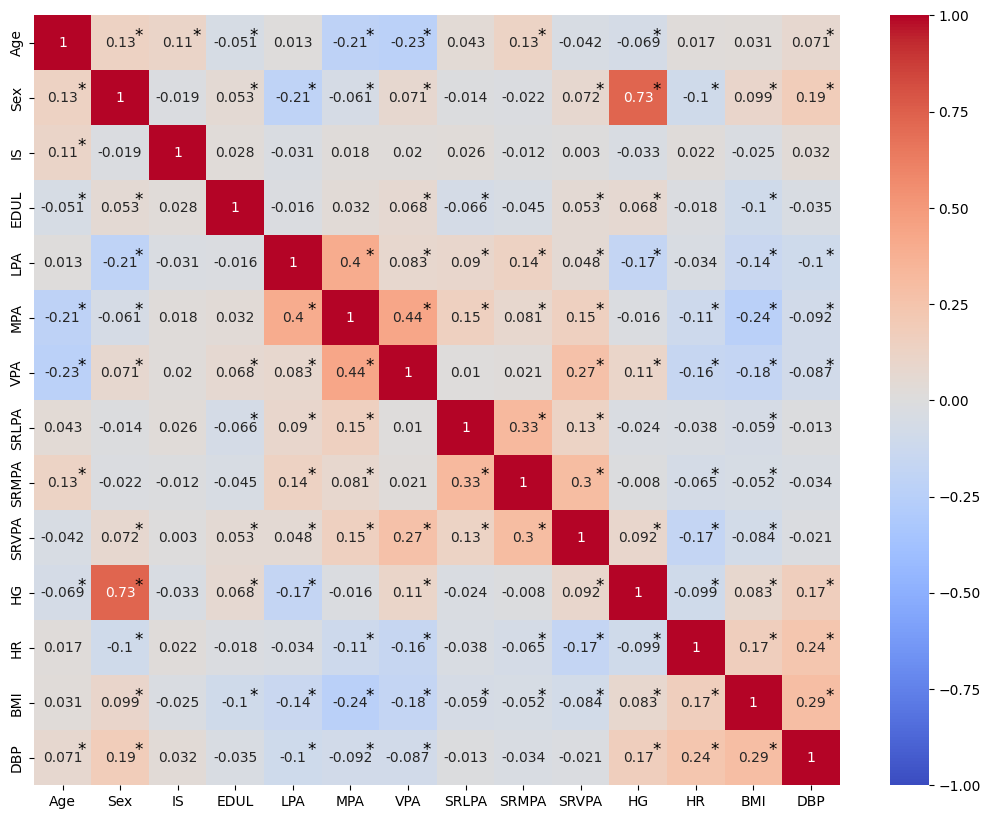

In [ ]:
corr_test = main_test
corr_test = corr_test[:]
del corr_test["BA"]
del corr_test["SBP"]
del corr_test["IS"]
corr = corr_test.corr()
corr = round(corr,3)

fig, ax = plt.subplots(figsize=(13,10)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)


p_values = np.asarray(calculate_pvalues(corr_test))

threshold = 0.0007575  # Define your significance threshold

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i != j:
            correlation = corr.iloc[i, j]
            p_value = p_values[i,j]  # Calculate or provide the p-value for the correlation

            if p_value < threshold:
                ax.text(j + 0.9, i + 0.2, "*", ha='right', va='top', color='black', fontsize=12)

# 6 Models OLS

## 6.1 PA BrainAGE Regression

### 6.1.1 Baseline Covariates

In [59]:
cov_model = ols('BA ~ Sex + Age + IS + EDUL', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     4.335
Date:                Fri, 29 Nov 2024   Prob (F-statistic):            0.00170
Time:                        20:14:39   Log-Likelihood:                -8649.2
No. Observations:                2712   AIC:                         1.731e+04
Df Residuals:                    2707   BIC:                         1.734e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3795      0.997     -0.380      0.7

### 6.1.2 Accelerometer PA

In [60]:
lpa = ols('BA ~ LPA + Age + Sex + IS + EDUL + Sex:LPA + EDUL:LPA', missing='drop', data = main_test).fit()
print(lpa.summary())

#calculate effect size
results = lpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.680
Date:                Fri, 29 Nov 2024   Prob (F-statistic):            0.00913
Time:                        20:14:39   Log-Likelihood:                -8648.5
No. Observations:                2712   AIC:                         1.731e+04
Df Residuals:                    2704   BIC:                         1.736e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6266      1.762      0.356      0.7

In [127]:
mpa = ols('BA ~ MPA + Age + Sex + IS + EDUL + Sex:MPA + EDUL:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.919
Date:                Fri, 29 Nov 2024   Prob (F-statistic):           0.000292
Time:                        22:21:28   Log-Likelihood:                -8644.2
No. Observations:                2712   AIC:                         1.730e+04
Df Residuals:                    2704   BIC:                         1.735e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1952      0.113     -1.726      0.0

In [62]:
vpa = ols('BA ~ VPA + Age + Sex + IS + EDUL + Sex:VPA + EDUL:VPA', missing='drop', data = main_test).fit()
print(vpa.summary())

#calculate effect size
results = vpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     4.385
Date:                Fri, 29 Nov 2024   Prob (F-statistic):           7.51e-05
Time:                        20:14:40   Log-Likelihood:                -8642.5
No. Observations:                2712   AIC:                         1.730e+04
Df Residuals:                    2704   BIC:                         1.735e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1516      1.071      0.142      0.8

### 6.1.3 Self-report PA

In [63]:
srlpa = ols('BA ~ SRLPA + Age + Sex + IS + EDUL + Sex:SRLPA + EDUL:SRLPA', missing='drop', data = main_test).fit()
print(srlpa.summary())

#calculate effect size
results = srlpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.689
Date:                Fri, 29 Nov 2024   Prob (F-statistic):            0.00892
Time:                        20:14:40   Log-Likelihood:                -8648.4
No. Observations:                2712   AIC:                         1.731e+04
Df Residuals:                    2704   BIC:                         1.736e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3154      1.043     -0.303      0.7

In [64]:
srmpa = ols('BA ~ SRMPA + Age + Sex + IS + EDUL + Sex:SRMPA + EDUL:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.885
Date:                Fri, 29 Nov 2024   Prob (F-statistic):           0.000322
Time:                        20:14:40   Log-Likelihood:                -8644.3
No. Observations:                2712   AIC:                         1.730e+04
Df Residuals:                    2704   BIC:                         1.735e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0010      1.026     -0.001      0.9

In [65]:
srvpa = ols('BA ~ SRVPA + Age + Sex + IS + EDUL + Sex:SRVPA + EDUL:SRVPA', missing='drop', data = main_test).fit()
print(srvpa.summary())

#calculate effect size
results = srvpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.773
Date:                Fri, 29 Nov 2024   Prob (F-statistic):           0.000444
Time:                        20:14:40   Log-Likelihood:                -8644.7
No. Observations:                2712   AIC:                         1.731e+04
Df Residuals:                    2704   BIC:                         1.735e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5645      1.019     -0.554      0.5

# 7 Model comparisons

## 7.1 Cov vs. PA

In [66]:
model_comparison = anova_lm(cov_model, lpa)
print(model_comparison)

   df_resid           ssr  df_diff    ss_diff         F    Pr(>F)
0    2707.0  93528.873433      0.0        NaN       NaN       NaN
1    2704.0  93479.323577      3.0  49.549855  0.477763  0.697777


In [128]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid           ssr  df_diff     ss_diff       F    Pr(>F)
0    2707.0  93528.873433      0.0         NaN     NaN       NaN
1    2704.0  93182.612461      3.0  346.260971  3.3493  0.018303


In [68]:
model_comparison = anova_lm(cov_model, vpa)
print(model_comparison)

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0    2707.0  93528.873433      0.0         NaN       NaN       NaN
1    2704.0  93071.336319      3.0  457.537114  4.430939  0.004102


## 7.2 Cov vs. SRPA

In [69]:
model_comparison = anova_lm(cov_model, srlpa)
print(model_comparison)

   df_resid           ssr  df_diff    ss_diff         F    Pr(>F)
0    2707.0  93528.873433      0.0        NaN       NaN       NaN
1    2704.0  93477.264037      3.0  51.609396  0.497632  0.683942


In [70]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0    2707.0  93528.873433      0.0         NaN       NaN       NaN
1    2704.0  93190.740414      3.0  338.133019  3.270395  0.020389


In [71]:
model_comparison = anova_lm(cov_model, srvpa)
print(model_comparison)

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0    2707.0  93528.873433      0.0         NaN       NaN       NaN
1    2704.0  93217.448344      3.0  311.425089  3.011215  0.029023


# 9 Standardization of all variables

In [72]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex","IS", "EDUL"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex","IS","EDUL"]], nan_policy='omit')

# 10 Mediation analysis

## 10.1 BMI

In [73]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
# print(res.summary())

In [74]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA + Age + Sex + IS + EDUL", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA + Age + Sex + IS + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

modelm = ols("BMI ~ MPA + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ BMI + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.067461       -0.123681       -0.015575    0.016
ACME (treated)           -0.067461       -0.123681       -0.015575    0.016
ADE (control)            -0.102645       -0.339974        0.128421    0.364
ADE (treated)            -0.102645       -0.339974        0.128421    0.364
Total effect             -0.170106       -0.399421        0.057616    0.134
Prop. mediated (control)  0.351345       -1.815125        4.602103    0.146
Prop. mediated (treated)  0.351345       -1.815125        4.602103    0.146
ACME (average)           -0.067461       -0.123681       -0.015575    0.016
ADE (average)            -0.102645       -0.339974        0.128421    0.364
Prop. mediated (average)  0.351345       -1.815125        4.602103    0.146
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.074
Model:

In [75]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
# print(res.summary())

## 10.2 DBP

In [76]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
# print(res.summary())

In [77]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA + Age + Sex + IS + EDUL", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA + Age + Sex + IS + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

modelm = ols("DBP ~ MPA + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ DBP + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.038508       -0.076823       -0.007957    0.014
ACME (treated)           -0.038508       -0.076823       -0.007957    0.014
ADE (control)            -0.122258       -0.351144        0.100604    0.304
ADE (treated)            -0.122258       -0.351144        0.100604    0.304
Total effect             -0.160766       -0.388343        0.059383    0.190
Prop. mediated (control)  0.196122       -2.249818        2.362948    0.196
Prop. mediated (treated)  0.196122       -2.249818        2.362948    0.196
ACME (average)           -0.038508       -0.076823       -0.007957    0.014
ADE (average)            -0.122258       -0.351144        0.100604    0.304
Prop. mediated (average)  0.196122       -2.249818        2.362948    0.196
                            OLS Regression Results                            
Dep. Variable:                    DBP   R-squared:                       0.045
Model:

In [78]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
# print(res.summary())

## 10.3 Heart rate

In [79]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
# print(res.summary())

In [80]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA + Age + Sex + EDUL", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA + Age + Sex + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HR ~ MPA + Age + Sex + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HR + Age + Sex + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.063911       -0.114756       -0.026284    0.002
ACME (treated)           -0.063911       -0.114756       -0.026284    0.002
ADE (control)            -0.090956       -0.299222        0.135523    0.428
ADE (treated)            -0.090956       -0.299222        0.135523    0.428
Total effect             -0.154867       -0.369446        0.070150    0.170
Prop. mediated (control)  0.352227       -2.471918        3.829233    0.172
Prop. mediated (treated)  0.352227       -2.471918        3.829233    0.172
ACME (average)           -0.063911       -0.114756       -0.026284    0.002
ADE (average)            -0.090956       -0.299222        0.135523    0.428
Prop. mediated (average)  0.352227       -2.471918        3.829233    0.172
                            OLS Regression Results                            
Dep. Variable:                     HR   R-squared:                       0.024
Model:

In [81]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
# print(res.summary())

## 10.4 Hand grip

In [82]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
# print(res.summary())

In [83]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA + Sex + Age + IS + EDUL", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA + Sex + Age + IS + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HG ~ MPA + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HG + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.002619       -0.012824        0.020673    0.718
ACME (treated)            0.002619       -0.012824        0.020673    0.718
ADE (control)            -0.166689       -0.380907        0.070677    0.144
ADE (treated)            -0.166689       -0.380907        0.070677    0.144
Total effect             -0.164071       -0.378960        0.067364    0.146
Prop. mediated (control) -0.008323       -0.334374        0.213041    0.744
Prop. mediated (treated) -0.008323       -0.334374        0.213041    0.744
ACME (average)            0.002619       -0.012824        0.020673    0.718
ADE (average)            -0.166689       -0.380907        0.070677    0.144
Prop. mediated (average) -0.008323       -0.334374        0.213041    0.744
                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.561
Model:

In [84]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + VPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ VPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
# print(res.summary())

# 11 LASSO Regression

## 11.1 Accelerometer PA

Optimal alpha: 0.02848035868435802


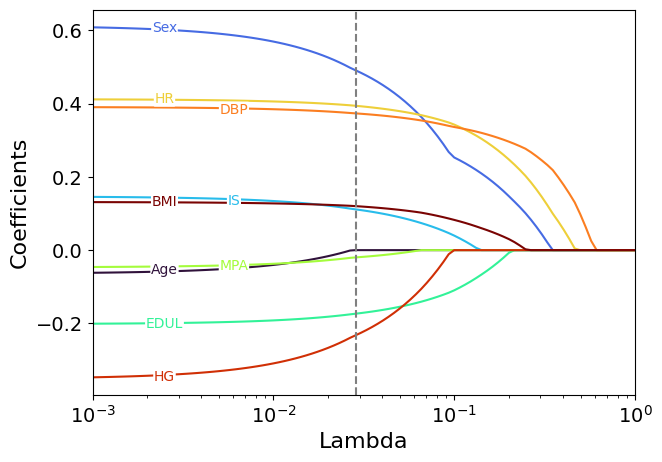

[-0.          0.49112501  0.11135479 -0.17359939 -0.01987464  0.39419968
  0.3734536  -0.2325979   0.12017054]
0.02128062783485185


In [118]:
df = main_test[["Age","Sex","IS", "EDUL", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age","Sex","IS", "EDUL", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age","Sex","IS", "EDUL", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)



cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,5))
for i, column in enumerate(columns):
    plt.plot(alphas, coefs[column], label=column, color=cmap(i / (len(columns) - 1)))

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 8.0)

    if i == 0:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -17),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 28),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 2:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(50, 3),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -10),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 4:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(50, -9),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(50, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -33),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 8:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
        
        
plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.xlim(0.001, 1)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, bbox_to_anchor=(1.01, 1.02), loc='upper left')
plt.legend().set_visible(False)
plt.show()




# Print the coefficients
print(coefficients)
print(r_squared)

## 11.2 Self-report PA

Optimal alpha: 0.02848035868435802


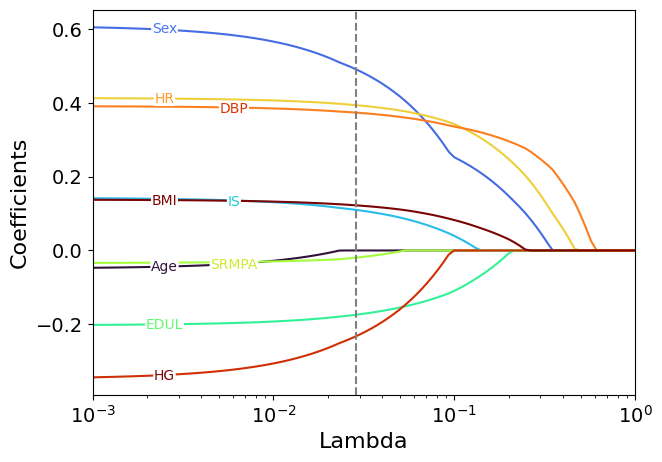

[-0.          0.49210721  0.11025236 -0.17459644 -0.01963299  0.39443266
  0.37413439 -0.2333617   0.12258171]
0.02128836136187806


In [123]:
df = main_test[["Age", "Sex", "IS", "EDUL", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Sex", "IS", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Sex", "IS", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,5))
for i, column in enumerate(columns):
    plt.plot(alphas, coefs[column], label=column, color=cmap(i / (len(columns) - 1)))

# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)


# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 7.0)
    
    if i == 0:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -15),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 26),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 2:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(50, 3),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -10),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 4:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(50, -8),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(50, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -31),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 8:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))


plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.xlim(0.001, 1)
plt.ylabel('Coefficients', fontsize = 16)
plt.legend().set_visible(False)
plt.show()


# Print the coefficients
print(coefficients)
print(r_squared)